In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.integrate import quad
from theta_class import AMMStationaryDistributionFast
from tqdm import tqdm

# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 1 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000,
}

# --- Analytical expectation via integration ---
def expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, total_step, S0, n_grid=2000, progress_bar=True):
    total_exp_fee = 0.0
    for step in tqdm(range(start_step+1, total_step+1), disable=not progress_bar):
        if step == 0:
            continue
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)

        # Construct the s-grid (log-space, wide enough to cover tails)
        low = np.exp(mean_ln - 5 * sd_ln)
        high = np.exp(mean_ln + 5 * sd_ln)
        s_grid = np.linspace(low, high, n_grid)

        # Evaluate fee and PDF
        fee_vals = model._expected_incoming_fee_v3(s0=s_grid)
        pdf_vals = lognorm.pdf(s_grid, s=sd_ln, scale=np.exp(mean_ln))

        # Integrate numerically
        val = np.trapezoid(fee_vals * pdf_vals, s_grid)
        total_exp_fee += val
    return total_exp_fee



# --- Combined Simulation + Integration Comparison ---
def compare_simulation_and_integration(total_steps, start_step, params, sim=True, plot=True, progress_bar=True):
    """
    Run GBM AMM simulation for total_steps and accumulate fees
    from start_step to total_steps.
    Compare simulation mean/std vs. integral-based expectation.
    """

    # --- Unpack params ---
    x0, y0, mu, sigma, gamma, dt = (
        params["x0"], params["y0"], params["mu"],
        params["sigma"], params["gamma"], params["dt"]
    )
    n_paths = params["n_paths"]
    L = np.sqrt(x0 * y0)
    # --- Build stationary theta model ---
    bins = np.linspace(-1.0, 1.0, params["N_bins"])
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    model = AMMStationaryDistributionFast(
        gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers
    )
    rng = np.random.default_rng(123)
    if sim:
        # --- Sample theta and compute initial S0 per path ---
        theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
        pi = model.pi_star / model.pi_star.sum()
        theta_samples = rng.choice(theta_list, size=n_paths, p=pi)
        s0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)

        # --- Generate GBM paths ---
        z = rng.normal(size=(total_steps, n_paths))
        t = np.linspace(0, total_steps * dt, total_steps + 1)[:, None]
        w = np.vstack([np.zeros((1, n_paths)), np.cumsum(np.sqrt(dt) * z, axis=0)])
        S = s0[None, :] * np.exp((mu - 0.5 * sigma**2) * t + sigma * w)

        # --- Initialize inventories and fee ---
        xt = np.full(n_paths, x0, dtype=float)
        yt = np.full(n_paths, y0, dtype=float)
        total_fee_window = np.zeros(n_paths)

        # --- Run simulation ---
        for i in range(1, total_steps+1):
            s1 = S[i, :]
            P_AMM = yt / xt
            bid = P_AMM * (1 - gamma)
            ask = P_AMM / (1 - gamma)

            up_mask = s1 > ask
            down_mask = s1 < bid

            if np.any(up_mask):
                x_new = L * np.sqrt(1 / ((1 - gamma) * s1[up_mask]))
                y_new = L * np.sqrt((1 - gamma) * s1[up_mask])
                fee_up = (gamma / (1 - gamma)) * (y_new - yt[up_mask])
                xt[up_mask] = x_new
                yt[up_mask] = y_new
                if i > start_step:
                    total_fee_window[up_mask] += fee_up

            if np.any(down_mask):
                x_new = L * np.sqrt((1 - gamma) / s1[down_mask])
                y_new = L * np.sqrt(s1[down_mask] / (1 - gamma))
                fee_down = (gamma / (1 - gamma)) * (x_new - xt[down_mask]) * s1[down_mask]
                xt[down_mask] = x_new
                yt[down_mask] = y_new
                if i > start_step:
                    total_fee_window[down_mask] += fee_down

        # --- Simulation stats ---
        sim_mean_fee = np.mean(total_fee_window)
        sim_std_fee = np.std(total_fee_window)

    # --- Analytical expectation ---
    analytical_exp_fee = expected_total_fee_over_future_fast(
        model, mu, sigma, dt, start_step, total_steps, S0=1.0, progress_bar=progress_bar
    )
    static_multiple_step_fee = model._expected_incoming_fee_vec() * (total_steps - start_step)
    naive_multiple_step_fee = model._incoming_fee_vec(theta=0.0) * (total_steps - start_step)
    print(f"simulation_mean:{sim_mean_fee}, simulation_std:{sim_std_fee}")
    print(f"ana:{analytical_exp_fee}, stat:{static_multiple_step_fee}, naiv:{naive_multiple_step_fee}")

    if sim and plot:
        # --- Plot results ---
        plt.figure(figsize=(8, 5))
        plt.hist(total_fee_window, bins=60, color="lightblue", edgecolor="k", density=True)
        plt.axvline(sim_mean_fee, color="r", linestyle="--", label=f"Sim mean: {sim_mean_fee:.3e}, std: {sim_std_fee:.3e}")
        plt.axvline(sim_mean_fee + sim_std_fee, color="gray", linestyle=":")
        plt.axvline(sim_mean_fee - sim_std_fee, color="gray", linestyle=":")
        plt.axvline(analytical_exp_fee, color="g", linestyle="-", linewidth=2,
                    label=f"Analytical: {analytical_exp_fee:.3e}")
        plt.axvline(static_multiple_step_fee, color="y", linestyle="--", linewidth=2,
                    label=f"Static: {static_multiple_step_fee:.3e}")
        plt.axvline(naive_multiple_step_fee, color="blue", linestyle="-", linewidth=2,
                    label=f"Naive: {naive_multiple_step_fee:.3e}")
        plt.legend()
        plt.xlabel(f"Total fee accumulated from step {start_step} → {total_steps}")
        plt.ylabel("Density")
        plt.title("Monte Carlo vs Analytical Expected Fee Comparison")
        # add the mean and std of the simulation as a text in the legend as exact values
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
        plt.show()
    if sim:
        return sim_mean_fee, analytical_exp_fee, static_multiple_step_fee, naive_multiple_step_fee
    else:
        print(f"ana:{analytical_exp_fee}, stat:{static_multiple_step_fee}, naiv:{naive_multiple_step_fee}")
        return analytical_exp_fee, static_multiple_step_fee, naive_multiple_step_fee


# # --- Run comparison example ---
# result = compare_simulation_and_integration(total_steps=10000, start_step=9000, params=params)
# print(result)


### Key Results 

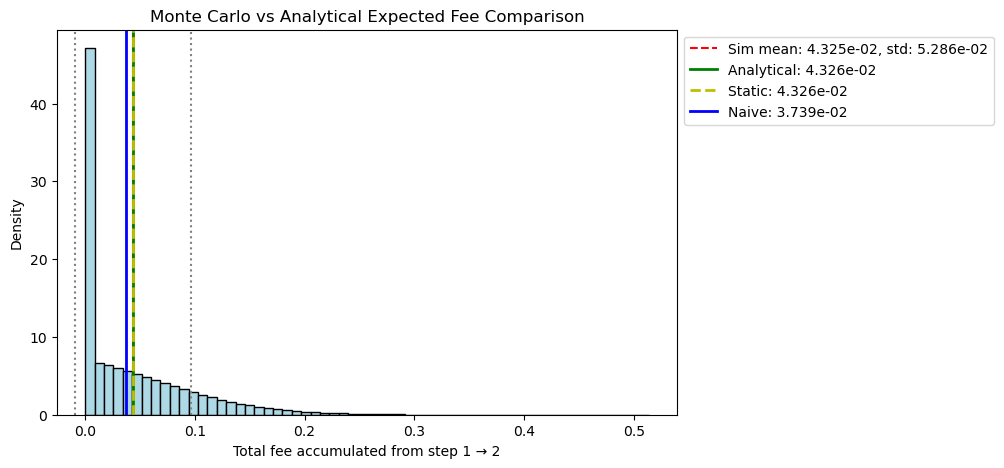

(np.float64(0.04324545472974031),
 np.float64(0.04326093934685449),
 0.04326097094137403,
 np.float64(0.037385569981170916))

In [90]:
N = int(2)
n = int(1)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

100%|██████████| 1/1 [00:00<00:00, 99.15it/s]


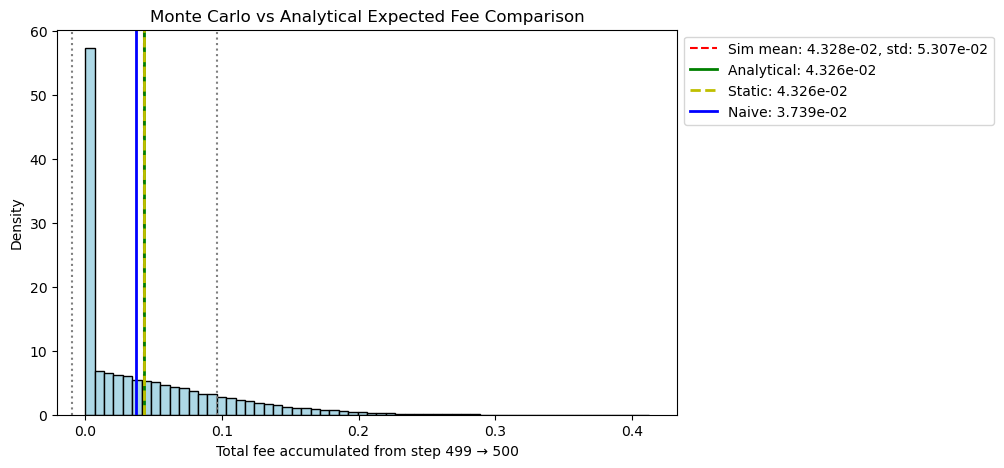

(np.float64(0.04328040748636138),
 np.float64(0.043259914612591516),
 0.04326097094137403,
 np.float64(0.037385569981170916))

In [104]:
N = int(500)
n = int(1)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_0000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

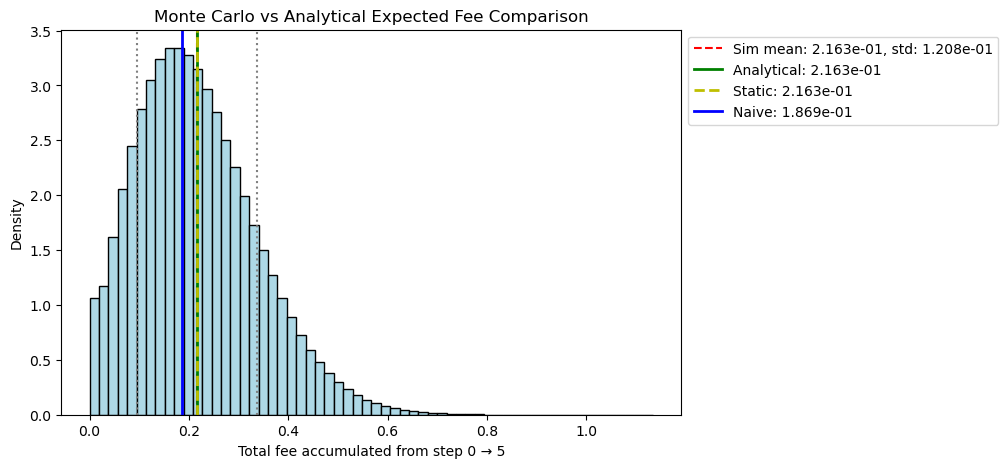

(np.float64(0.21629318883770407),
 np.float64(0.2163046864456559),
 0.21630485470687016,
 np.float64(0.1869278499058546))

In [91]:
N = int(5)
n = int(5)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

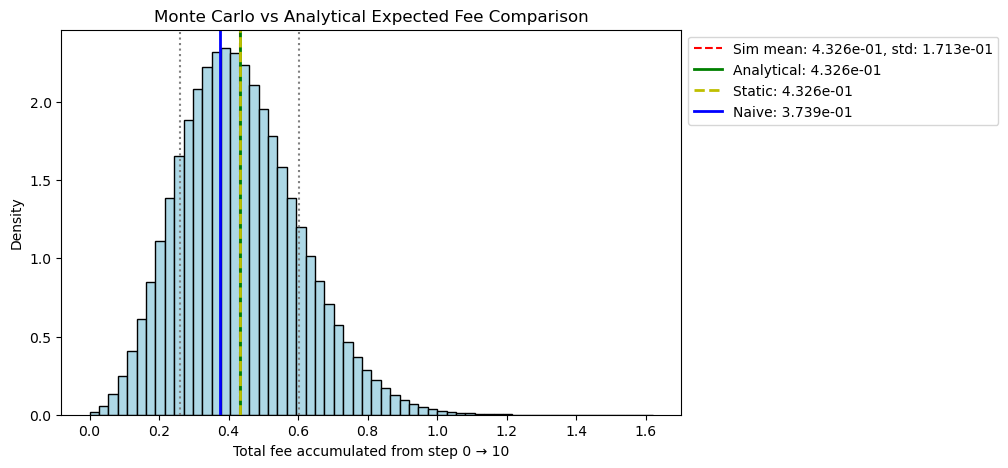

(np.float64(0.4325741266231052),
 np.float64(0.4326093214482263),
 0.43260970941374033,
 np.float64(0.3738556998117092))

In [92]:
N = int(10)
n = int(10)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

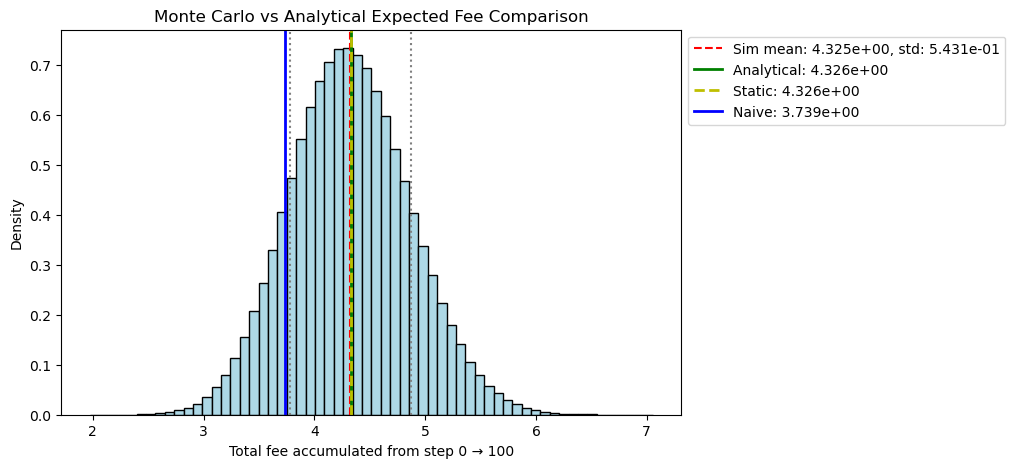

(np.float64(4.325009160403421),
 np.float64(4.3260839547411605),
 4.326097094137403,
 np.float64(3.7385569981170916))

In [95]:
N = int(100)
n = int(100)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_00000,
}
compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=True)

In [98]:
N = int(10000)
n = int(10000)
# --- Global Parameters ---
params = {
    "x0": 1e6,
    "y0": 1e6,
    "mu": 0.0,
    "sigma": 1,
    "gamma": 0.0003,
    "dt": 12 / (365 * 24 * 60 * 60),
    "N_bins": 500,
    "n_paths": 10_000000,
}
ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)

print(ana, stat, naiv)

100%|██████████| 10000/10000 [01:17<00:00, 128.22it/s]

432.50655445146907 432.6097094137403 373.85569981170914


100%|██████████| 1/1 [00:18<00:00, 18.48s/it]

simulation_mean:0.6878361466973647, simulation_std:0.5651187716124988
ana:0.6872194145123459, stat:0.6937723572249344, naiv:0.6929255040421621


Text(0.5, 1.0, 'Effect of Simulation Length N on Expected Fees')

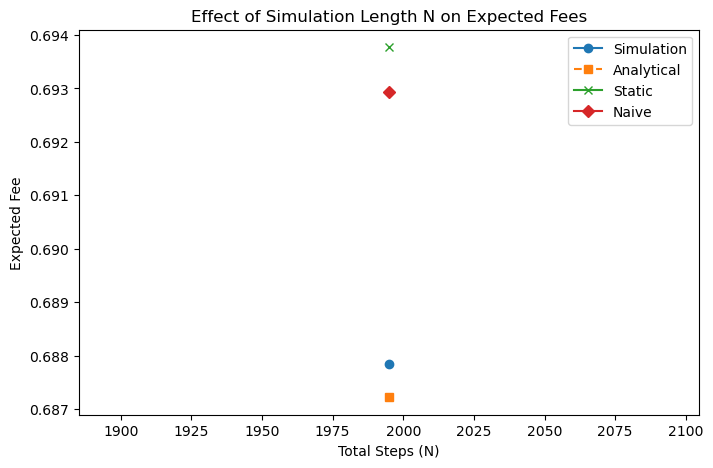

In [114]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(1995, 2000, 5)):
    n = int(1)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 10,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 1_00_000,
    }
    sim, ana, stat, naiv = compare_simulation_and_integration(total_steps=N,
                                                              start_step=N-n,
                                                              params=params,
                                                              sim=True,
                                                              plot=False,
                                                              progress_bar=False)
    results.append({
        "total_steps": N,
        "sim": sim,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

In [115]:
(0.6872194145123459 - 0.6878361466973647) / (0.5651187716124988 / np.sqrt(1_00_000))

np.float64(-0.34510947237283507)

In [116]:
(0.6937723572249344 - 0.6878361466973647) / (0.5651187716124988 / np.sqrt(1_00_000))

np.float64(3.3217700208093177)

In [112]:
(0.6904959898732829 - 0.6885822182249637) / (0.5589501495353388/np.sqrt(1_00_000))

np.float64(1.082722195382605)

In [113]:
(0.6937723572249344 - 0.6885822182249637) / (0.5589501495353388/np.sqrt(1_00_000))

np.float64(2.93633710026197)

100%|██████████| 2000/2000 [00:30<00:00, 65.82it/s]


Text(0.5, 1.0, 'Effect of Simulation Length N on Expected Fees')

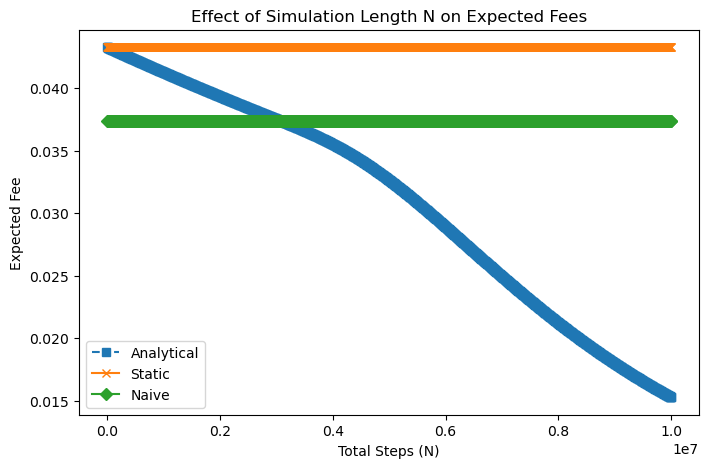

In [78]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(1, 10000000, 5000)):
    n = int(1)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }
    ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)
    results.append({
        "total_steps": N,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
# plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

1999999 -> 20000000

1999999999 -> 

100%|██████████| 20/20 [01:25<00:00,  4.30s/it]


Text(0.5, 1.0, 'Effect of Simulation Length N on Expected Fees')

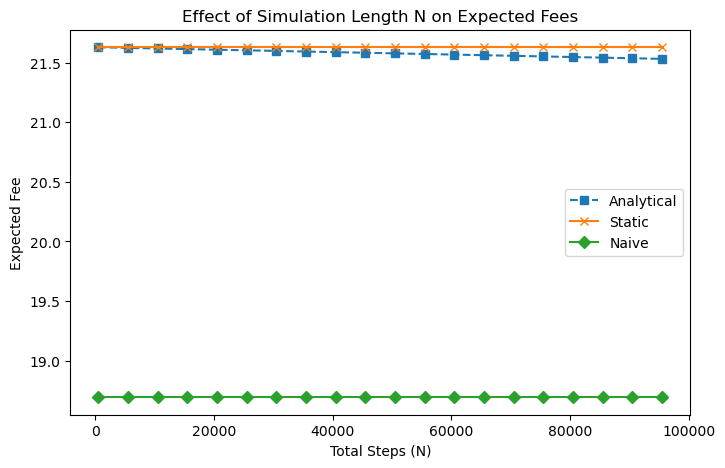

In [82]:
# N = int(2)
from tqdm import tqdm
import pandas as pd
results = []
for N in tqdm(np.arange(500, 100000, 5000)):
    n = int(500)
    # --- Global Parameters ---
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }
    ana, stat, naiv = compare_simulation_and_integration(total_steps=N, start_step=N-n, params=params, sim=False, plot=False)
    results.append({
        "total_steps": N,
        "ana": ana,
        "stat": stat,
        "naiv": naiv
    })
    
results = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
# plt.plot(results['total_steps'], results['sim'], 'o-', label='Simulation')
plt.plot(results['total_steps'], results['ana'], 's--', label='Analytical')
plt.plot(results['total_steps'], results['stat'], 'x-', label='Static')
plt.plot(results['total_steps'], results['naiv'], 'D-', label='Naive')
plt.legend()
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")

100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


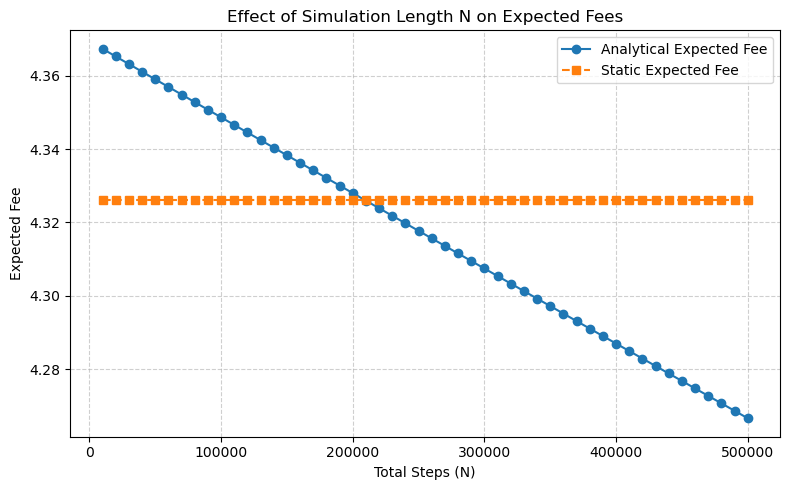

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Storage ---
results = []

# --- Parameter sweep over N ---
for N in tqdm(np.arange(10000, 500001, 10000)):  # 500, 1000, ..., 5000
    n = 100  # accumulation window
    
    params = {
        "x0": 1e6,
        "y0": 1e6,
        "mu": 0.0,
        "sigma": 1.0,
        "gamma": 0.0003,
        "dt": 12 / (365 * 24 * 60 * 60),
        "N_bins": 500,
        "n_paths": 10_000,
    }

    analytical_exp_fee, static_multiple_step_fee = compare_simulation_and_integration(
        total_steps=N, start_step=N - n, params=params, sim=False
    )

    results.append({
        "N": N,
        "analytical_exp_fee": analytical_exp_fee,
        "static_multiple_step_fee": static_multiple_step_fee
    })

# --- Convert to arrays for plotting ---
N_values = [r["N"] for r in results]
analytical_vals = [r["analytical_exp_fee"] for r in results]
static_vals = [r["static_multiple_step_fee"] for r in results]

# --- Plot comparison ---
plt.figure(figsize=(8, 5))
plt.plot(N_values, analytical_vals, 'o-', label='Analytical Expected Fee')
plt.plot(N_values, static_vals, 's--', label='Static Expected Fee')
plt.xlabel("Total Steps (N)")
plt.ylabel("Expected Fee")
plt.title("Effect of Simulation Length N on Expected Fees")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [1]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad
import time
from theta_class import AMMStationaryDistributionFast

# ============================================================
# --- Original slow version (quad integration) ---------------
# ============================================================
def expected_total_fee_over_future_quad(model, mu, sigma, dt, start_step, end_step, S0):
    total_exp_fee = 0.0
    for step in range(start_step, end_step + 1):
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)

        def integrand(s):
            return model._expected_incoming_fee_v2(s0=s) * lognorm.pdf(s, s=sd_ln, scale=np.exp(mean_ln))

        low = np.exp(mean_ln - 5 * sd_ln)
        high = np.exp(mean_ln + 5 * sd_ln)
        val, _ = quad(integrand, low, high, limit=200, epsabs=1e-8)
        total_exp_fee += val
    return total_exp_fee


# ============================================================
# --- Fast vectorized version (trapezoidal integration) ------
# ============================================================
def expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, end_step, S0, n_points=400):
    total_exp_fee = 0.0
    for step in range(start_step, end_step + 1):
        t = step * dt
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln = sigma * np.sqrt(t)
        s_grid = np.exp(np.linspace(mean_ln - 5 * sd_ln, mean_ln + 5 * sd_ln, n_points))
        pdf_vals = lognorm.pdf(s_grid, s=sd_ln, scale=np.exp(mean_ln))
        fee_vals = model._expected_incoming_fee_v3(s_grid)
        val = np.trapz(fee_vals * pdf_vals, s_grid)
        total_exp_fee += val
    return total_exp_fee


# ============================================================
# --- Test both methods side-by-side --------------------------
# ============================================================
def compare_integration_methods():
    # Parameters
    x0, y0 = 1e6, 1e6
    mu, sigma, gamma = 0.0, 0.2, 0.0003
    dt = 1 / (365 * 24)
    start_step, end_step = 1, 500

    # Model
    N_bins = 500
    bins = np.linspace(-1.0, 1.0, N_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt,
                                          bins=bins, bin_centers=bin_centers)

    # --- Quad version ---
    t0 = time.time()
    val_quad = expected_total_fee_over_future_quad(model, mu, sigma, dt, start_step, end_step, S0=1.0)
    t1 = time.time()

    # --- Fast vectorized version ---
    val_fast = expected_total_fee_over_future_fast(model, mu, sigma, dt, start_step, end_step, S0=1.0, n_points=400)
    t2 = time.time()

    # --- Compare results ---
    print(f"Original quad integration: {val_quad:.6e} (time: {t1 - t0:.2f}s)")
    print(f"Fast trapezoidal version:  {val_fast:.6e} (time: {t2 - t1:.2f}s)")
    print(f"Absolute diff: {abs(val_quad - val_fast):.3e}")
    print(f"Relative diff: {abs(val_quad - val_fast) / abs(val_quad):.2%}")


# ============================================================
# --- Run test ------------------------------------------------
# ============================================================
if __name__ == "__main__":
    compare_integration_methods()


/var/folders/f8/wwwwfy_x5tl686n3tb4qn5x40000gn/T/ipykernel_8800/1079543592.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.trapz(fee_vals * pdf_vals, s_grid)


Original quad integration: 1.077136e+02 (time: 5.20s)
Fast trapezoidal version:  1.077137e+02 (time: 0.83s)
Absolute diff: 1.281e-05
Relative diff: 0.00%


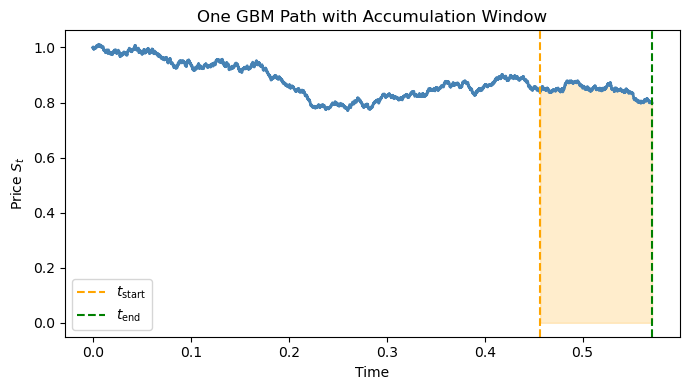

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu, sigma, dt, steps = 0.0, 0.2, 1/(365*24), 5000
S0 = 1.0
rng = np.random.default_rng(42)

# --- Generate GBM path ---
t = np.linspace(0, steps * dt, steps + 1)
W = np.concatenate([[0], np.cumsum(np.sqrt(dt) * rng.normal(size=steps))])
S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# --- Define accumulation window ---
start_step, end_step = 4000, 5000

plt.figure(figsize=(7, 4))
plt.plot(t, S, color="steelblue", lw=2)
plt.axvline(t[start_step], color="orange", linestyle="--", label=r"$t_{\text{start}}$")
plt.axvline(t[end_step], color="green", linestyle="--", label=r"$t_{\text{end}}$")
plt.fill_between(t[start_step:end_step+1], S[start_step:end_step+1], color="orange", alpha=0.2)
plt.xlabel("Time")
plt.ylabel("Price $S_t$")
plt.title("One GBM Path with Accumulation Window")
plt.legend()
plt.tight_layout()
plt.savefig("gbm_window.png", dpi=300)
plt.show()
